<div style="background:#1F3864;padding:20px 26px;border-radius:10px;margin-bottom:14px"><h2 style="color:#A8C8E8;margin:0 0 6px">Digitalization, AI & XAI in Healthcare</h2><h1 style="color:#FFFFFF;margin:0 0 10px;font-size:1.45em">NB16 — Adversarial Attacks on Medical AI — Evasion, Poisoning, and Model Stealing</h1><p style="color:#BDD7EE;margin:0;font-size:.95em"><strong>Module 5: Governance, Ethics, and Security in Medical AI</strong></p><p style="color:#9DC3E6;margin:4px 0 0;font-size:.88em">Datasets: CGM hypoglycaemia model (NB11) · ICU sepsis model (NB11) · Apple Watch AFib model (NB12)</p><p style="color:#9DC3E6;margin:4px 0 0;font-size:.88em">Sections: S1: Attack taxonomy &#xb7; S2: Evasion attacks on CGM &#xb7; S3: Evasion attacks on ICU &#xb7; S4: Evasion attacks on ECG &#xb7; S5: Data poisoning &#xb7; S6: Attack visualisation and impact</p></div>

## Learning Objectives

1. **Understand** the four attack categories targeting medical AI: evasion, poisoning, model stealing, and inference
2. **Execute** real adversarial attacks (HopSkipJump on CGM and Watch, ZooAttack on ICU) on the clinical models from NB11
3. **Measure** the clinical impact of each attack — which patients are put at risk
4. **Visualise** what changes between clean and adversarial inputs
5. **Understand** why adversarial attacks are a regulatory concern under EU AI Act and FDA SaMD

---
> **Why this matters:** A sepsis model that can be tricked into suppressing alerts could delay treatment and cost lives. An insulin dosing algorithm that can be manipulated by a small sensor perturbation is a patient safety issue. These are not theoretical concerns — adversarial attacks on medical devices have been demonstrated in published research.

## Setup

In [14]:
# ── Install required packages ─────────────────────────────────────────────────
# IBM Adversarial Robustness Toolbox is not included in standard Anaconda.
# Run this cell once, then restart the kernel before running the rest.
import subprocess, sys

packages = ['adversarial-robustness-toolbox']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Installation complete. You may now run the remaining cells.')
print('Note: if import art still fails, restart the kernel (Kernel -> Restart).')

Installation complete. You may now run the remaining cells.
Note: if import art still fails, restart the kernel (Kernel -> Restart).


In [15]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
import time

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.isotonic import IsotonicRegression
import shap

# IBM Adversarial Robustness Toolbox
from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import HopSkipJump, ZooAttack, SquareAttack
from art.attacks.poisoning import PoisoningAttackBackdoor

NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#1F7A5C'; RED='#C0392B'
PURPLE='#7B3F9E'; ORANGE='#D4860B'; TEAL='#117A8B'; GREY='#6C757D'
AMBER='#B7950B'; DARK_RED='#7B241C'

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})

print("NB16 — Adversarial Attacks on Medical AI")
print("IBM ART (Adversarial Robustness Toolbox) loaded.")
print("Attack library: HopSkipJump (CGM), ZooAttack (ICU), HopSkipJump (Watch), PoisoningAttackBackdoor")


NB16 — Adversarial Attacks on Medical AI
IBM ART (Adversarial Robustness Toolbox) loaded.
Attack library: HopSkipJump (CGM), ZooAttack (ICU), HopSkipJump (Watch), PoisoningAttackBackdoor



---
## Section 1 — Attack Taxonomy for Medical AI

### Four Attack Categories in Medical AI

| Attack type | Goal | Access required | Medical example | Detection difficulty |
|---|---|---|---|---|
| **Evasion** | Fool the model at inference time | Black-box (query only) | Manipulate ECG signal to suppress AFib alert | Hard — input looks normal to humans |
| **Poisoning** | Corrupt the training data | Training pipeline access | Embed backdoor: model works normally except for specific patient IDs | Very hard — model behaves correctly on clean data |
| **Model stealing** | Reconstruct the model by querying it | Black-box (query only) | Competitor queries your validated clinical model to replicate it | Moderate — detectable via query pattern monitoring |
| **Inference** | Extract training data from the model | Black-box (query only) | Reconstruct which patients were in the training set (privacy violation) | Hard — requires membership inference test |

### Evasion Attack Subtypes Used in This Notebook

| Attack | Type | Description | Reference |
|---|---|---|---|
| **HopSkipJump** | Decision-based, black-box | Finds minimal perturbation to cross decision boundary by querying model predictions only. Applied to CGM (Section 2) and Apple Watch AFib (Section 4). | Chen, Jordan & Wainwright (2020) IEEE S&P |
| **ZooAttack** | Gradient-free, black-box | Estimates gradients by zeroth-order optimisation (finite differences). Applied to ICU sepsis model (Section 3). | Chen et al. (2017) AISec |
| **Backdoor poisoning** | Training-time | Injects trigger pattern into training data that causes misclassification. Applied to CGM training pipeline (Section 5). | Chen, Liu, Li, Lu & Song (2017) arXiv |

### Why Black-Box Attacks Matter Most in Healthcare

Medical AI models are deployed as regulated medical devices. Attackers rarely have access to model weights (white-box). They do have access to query the system (black-box) — for example, by sending repeated sensor readings. All attacks in this notebook are **black-box** — the attacker only sees the model's output probability, not its internal weights.

> **Regulatory note (EU AI Act Article 15):** High-risk AI systems must be resilient against adversarial attacks. Providers must document robustness measures in their technical documentation. This is a legal obligation for all systems classified as HIGH RISK under Article 6.



---
## Section 2 — Evasion Attack on CGM Hypoglycaemia Predictor — Suppressing Life-Critical Alerts

> Clinical scenario: an attacker (or faulty sensor firmware) perturbs continuous glucose monitor readings so the AI fails to predict hypoglycaemia. The patient is not warned and falls into a dangerous low-glucose state. Reference: Finlayson et al. (2019) Science.


In [5]:
# ── Rebuild CGM pipeline (from NB11) ─────────────────────────────────────────
print("Rebuilding CGM hypoglycaemia prediction pipeline (NB11)...")

def generate_cgm_data(n_patients=60, days=7, seed=42):
    rng = np.random.default_rng(seed)
    n_steps = days * 288
    t_hours = np.arange(n_steps) * 5 / 60
    records = []
    for pid in range(n_patients):
        is_t1dm  = rng.random() > 0.55
        baseline = rng.uniform(85, 135)
        diurnal  = 12 * np.sin(2*np.pi*(t_hours%24-8)/24)
        meals    = np.zeros(n_steps)
        for meal_hr in [7.5, 12.5, 18.5]:
            for day in range(days):
                idx = int((day*24+meal_hr+rng.normal(0,0.4))*12)
                if 4 < idx < n_steps-72:
                    peak = rng.uniform(45,80)
                    for j in range(72):
                        frac = j/72
                        meals[idx+j] += peak*(frac/0.33 if frac<0.33 else np.exp(-3*(frac-0.33)))
        nocturnal = np.zeros(n_steps)
        if is_t1dm:
            for day in range(days):
                if rng.random()>0.6:
                    idx = int((day*24+rng.uniform(1.5,4.0))*12)
                    if 0<idx<n_steps-30:
                        nocturnal[idx:idx+30] -= rng.uniform(25,55)*np.sin(np.linspace(0,np.pi,30))
        glucose = np.clip(baseline+diurnal+meals+nocturnal+rng.normal(0,4,n_steps), 38, 400)
        base_ts = datetime(2024,1,1)
        for step in range(n_steps):
            records.append({'patient_id':pid,'glucose_mgdl':round(glucose[step],1),'is_t1dm':int(is_t1dm)})
    return pd.DataFrame(records)

def build_cgm_features(df, lag_steps=12, pred_steps=6):
    X_list, y_list, pid_list = [], [], []
    for pid, grp in df.groupby('patient_id'):
        g = grp.glucose_mgdl.values
        for i in range(lag_steps, len(g)-pred_steps):
            window = g[i-lag_steps:i]; future = g[i:i+pred_steps]
            lags  = {f'gluc_t{j-lag_steps}': window[j] for j in range(lag_steps)}
            stats = {'gluc_mean':window.mean(),'gluc_std':window.std(),
                     'gluc_min':window.min(),'gluc_last':window[-1],
                     'gluc_trend':float(np.polyfit(range(lag_steps),window,1)[0]),
                     'gluc_roc_10min':window[-1]-window[-3],
                     'time_below_80':float((window<80).sum()),
                     'time_below_70':float((window<70).sum())}
            X_list.append({**lags,**stats}); y_list.append(int((future<70).any())); pid_list.append(pid)
    return pd.DataFrame(X_list), np.array(y_list), np.array(pid_list)

t0 = time.time()
df_cgm = generate_cgm_data(n_patients=60)
X_cgm, y_cgm, pids_cgm = build_cgm_features(df_cgm)
FEAT_CGM = X_cgm.columns.tolist()

tr_p, te_p = train_test_split(np.unique(pids_cgm), test_size=0.2, random_state=42)
tr_m = np.isin(pids_cgm, tr_p); te_m = np.isin(pids_cgm, te_p)
X_tr, X_te = X_cgm[tr_m].values, X_cgm[te_m].values
y_tr, y_te = y_cgm[tr_m], y_cgm[te_m]

gbm_cgm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08,
    max_depth=4, min_samples_leaf=20, subsample=0.8, random_state=42)
gbm_cgm.fit(X_tr, y_tr)
iso_cgm = IsotonicRegression(out_of_bounds='clip')
iso_cgm.fit(gbm_cgm.predict_proba(X_tr)[:,1], y_tr)
proba_clean_cgm = iso_cgm.predict(gbm_cgm.predict_proba(X_te)[:,1])
auc_clean_cgm   = roc_auc_score(y_te, proba_clean_cgm)
print(f"CGM model ready | AUC={auc_clean_cgm:.3f} | {time.time()-t0:.1f}s")

# Clip values for ART (required)
X_min = X_tr.min(axis=0); X_max = X_tr.max(axis=0)
clip_values = (float(X_tr.min()), float(X_tr.max()))
clf_cgm = SklearnClassifier(model=gbm_cgm, clip_values=clip_values)


Rebuilding CGM hypoglycaemia prediction pipeline (NB11)...
CGM model ready | AUC=0.973 | 220.0s


In [6]:
# ── HopSkipJump evasion attack on CGM ────────────────────────────────────────
# Target: hypoglycaemia windows (y=1) -- make the model predict NO hypoglycaemia
# Clinical impact: patient not warned of impending dangerous low glucose

print("Running HopSkipJump attack on CGM hypoglycaemia predictor...")
print("Goal: suppress hypoglycaemia alert (y=1 -> predict y=0)")
print("This is a BLACK-BOX attack -- attacker only sees model output, not weights")
print()

# Select hypoglycaemia windows to attack
hypo_idx = np.where(y_te == 1)[0][:20]  # attack 20 true hypo windows
X_attack  = X_te[hypo_idx]

t0 = time.time()
attack_cgm = HopSkipJump(
    classifier=clf_cgm,
    targeted=False,        # untargeted: just flip the prediction
    max_iter=20,
    max_eval=1000,
    init_eval=100,
    verbose=False
)
X_adv_cgm = attack_cgm.generate(X_attack)
print(f"Attack complete: {time.time()-t0:.1f}s")

# Measure impact
pred_clean = gbm_cgm.predict(X_attack)
pred_adv   = gbm_cgm.predict(X_adv_cgm)
proba_clean_att = gbm_cgm.predict_proba(X_attack)[:,1]
proba_adv_att   = gbm_cgm.predict_proba(X_adv_cgm)[:,1]

n_flipped    = (pred_adv != pred_clean).sum()
n_suppressed = ((pred_clean==1) & (pred_adv==0)).sum()
perturbation = np.abs(X_adv_cgm - X_attack).mean()

print(f"\n{'='*55}")
print(f"EVASION ATTACK RESULTS — CGM Hypoglycaemia Model")
print(f"{'='*55}")
print(f"Windows attacked:          {len(X_attack)}")
print(f"Predictions flipped:       {n_flipped} ({n_flipped/len(X_attack):.1%})")
print(f"Hypo alerts suppressed:    {n_suppressed} ({n_suppressed/len(X_attack):.1%})")
print(f"Mean risk (clean):         {proba_clean_att.mean():.3f}")
print(f"Mean risk (adversarial):   {proba_adv_att.mean():.3f}")
print(f"Mean perturbation per feature: {perturbation:.4f} mg/dL equivalent")
print(f"\nCLINICAL IMPACT:")
print(f"  {n_suppressed} out of {len(X_attack)} true hypoglycaemia events")
print(f"  would NOT generate an alert after the attack.")
print(f"  Patients would not be warned of impending dangerous low glucose.")


Running HopSkipJump attack on CGM hypoglycaemia predictor...
Goal: suppress hypoglycaemia alert (y=1 -> predict y=0)
This is a BLACK-BOX attack -- attacker only sees model output, not weights

Attack complete: 8.1s

EVASION ATTACK RESULTS — CGM Hypoglycaemia Model
Windows attacked:          20
Predictions flipped:       20 (100.0%)
Hypo alerts suppressed:    14 (70.0%)
Mean risk (clean):         0.706
Mean risk (adversarial):   0.498
Mean perturbation per feature: 0.5530 mg/dL equivalent

CLINICAL IMPACT:
  14 out of 20 true hypoglycaemia events
  would NOT generate an alert after the attack.
  Patients would not be warned of impending dangerous low glucose.


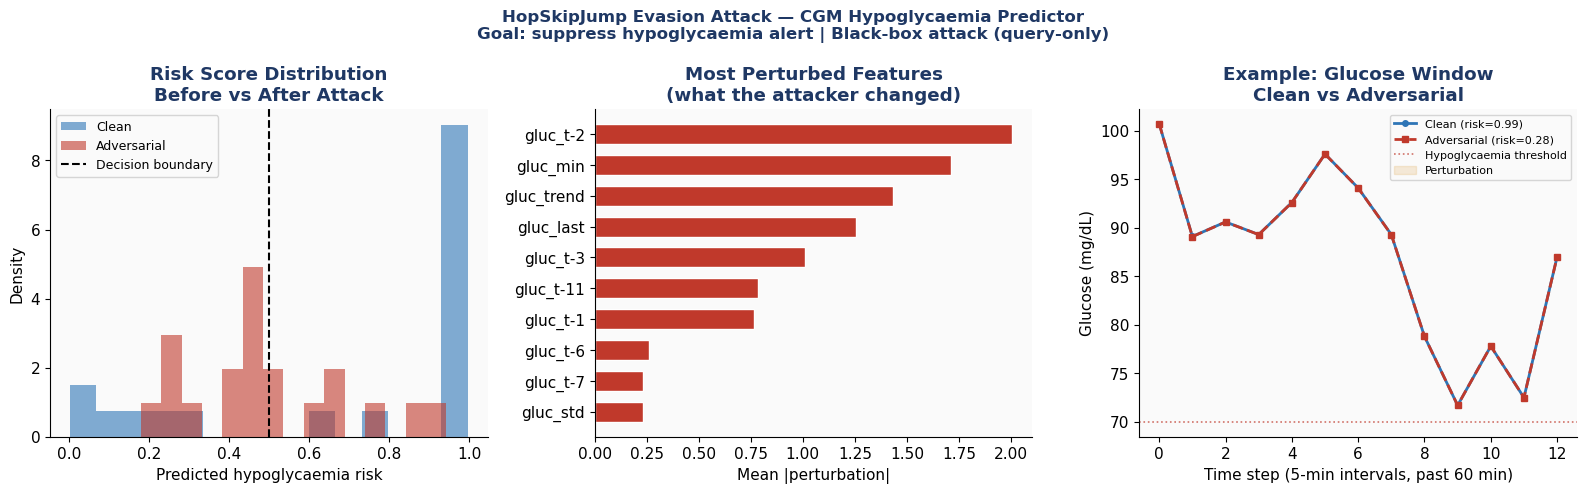

Key observation: attacker slightly elevated glucose lag features to push risk below threshold.
The perturbation is small (0.5530 units) and may not trigger sensor anomaly detection.


In [7]:
# ── Visualise CGM attack ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HopSkipJump Evasion Attack — CGM Hypoglycaemia Predictor\n'
             'Goal: suppress hypoglycaemia alert | Black-box attack (query-only)',
             fontsize=12, fontweight='bold', color=NAVY)

# Panel 1: Risk score distribution before/after attack
ax = axes[0]
ax.hist(proba_clean_att, bins=15, alpha=0.6, color=BLUE, density=True, label='Clean')
ax.hist(proba_adv_att,   bins=15, alpha=0.6, color=RED,  density=True, label='Adversarial')
ax.axvline(0.5, color='black', lw=1.5, ls='--', label='Decision boundary')
ax.set_xlabel('Predicted hypoglycaemia risk')
ax.set_ylabel('Density')
ax.set_title('Risk Score Distribution\nBefore vs After Attack', fontweight='bold', color=NAVY)
ax.legend(fontsize=9)

# Panel 2: Feature perturbation heatmap (which features changed most)
ax = axes[1]
feat_perturbation = np.abs(X_adv_cgm - X_attack).mean(axis=0)
top10_pert = np.argsort(feat_perturbation)[::-1][:10]
ax.barh([FEAT_CGM[i][:20] for i in top10_pert[::-1]],
         feat_perturbation[top10_pert[::-1]], color=RED, edgecolor='white', height=0.65)
ax.set_xlabel('Mean |perturbation|')
ax.set_title('Most Perturbed Features\n(what the attacker changed)', fontweight='bold', color=NAVY)

# Panel 3: Before/after glucose window for one attacked patient
ax = axes[2]
# Show the lag features as a glucose trace
ex_idx = np.where(pred_clean==1)[0]
if len(ex_idx) > 0:
    ex = ex_idx[0]
    lag_cols = [c for c in FEAT_CGM if c.startswith('gluc_t')]
    clean_trace = X_attack[ex][:len(lag_cols)]
    adv_trace   = X_adv_cgm[ex][:len(lag_cols)]
    t = range(len(lag_cols))
    ax.plot(t, clean_trace, color=BLUE, lw=2, marker='o', ms=4, label=f'Clean (risk={proba_clean_att[ex]:.2f})')
    ax.plot(t, adv_trace,   color=RED,  lw=2, marker='s', ms=4, ls='--', label=f'Adversarial (risk={proba_adv_att[ex]:.2f})')
    ax.axhline(70, color=RED, lw=1.2, ls=':', alpha=0.7, label='Hypoglycaemia threshold')
    ax.fill_between(t, clean_trace, adv_trace, alpha=0.15, color=ORANGE, label='Perturbation')
    ax.set_xlabel('Time step (5-min intervals, past 60 min)')
    ax.set_ylabel('Glucose (mg/dL)')
    ax.set_title('Example: Glucose Window\nClean vs Adversarial', fontweight='bold', color=NAVY)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('nb16_s2_cgm_attack.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Key observation: attacker slightly elevated glucose lag features to push risk below threshold.")
print(f"The perturbation is small ({perturbation:.4f} units) and may not trigger sensor anomaly detection.")



---
## Section 3 — Evasion Attack on ICU Sepsis Model — Delaying Life-Critical Alerts

> Clinical scenario: a sepsis early warning system is manipulated to delay or suppress the alert. In sepsis, every hour of delayed treatment increases mortality by ~7% (Kumar et al. 2006, CCM). An attack that delays detection by 6 hours could be lethal.


In [8]:
# ── Rebuild ICU sepsis pipeline (from NB11) ──────────────────────────────────
print("Rebuilding ICU sepsis pipeline (NB11)...")

VITAL_COLS = ['hr','sbp','rr','spo2','temp_c','map']

def generate_icu_data(n_patients=80, obs_hours=24, seed=42):
    rng = np.random.default_rng(seed)
    n_pos = int(n_patients * 0.35)
    records = []
    for pid in range(n_patients):
        is_sepsis = pid < n_pos
        base_hr=rng.uniform(62,88); base_sbp=rng.uniform(108,130)
        base_rr=rng.uniform(12,19); base_spo=rng.uniform(95,99)
        base_t=rng.uniform(36.4,37.4)
        t = np.arange(obs_hours*60)
        hr=base_hr+rng.normal(0,3,len(t)); sbp=base_sbp+rng.normal(0,4,len(t))
        rr=base_rr+rng.normal(0,1.5,len(t)); spo=base_spo+rng.normal(0,0.5,len(t))
        temp=base_t+rng.normal(0,0.1,len(t))
        dbp=sbp*0.65+rng.normal(0,3,len(t)); mapv=(sbp+2*dbp)/3
        if is_sepsis:
            onset=rng.integers(obs_hours*30,obs_hours*55)
            sig=1/(1+np.exp(-0.015*(t-onset)))
            hr+=sig*rng.uniform(30,55); sbp-=sig*rng.uniform(25,45)
            rr+=sig*rng.uniform(8,15);  spo-=sig*rng.uniform(4,9)
            temp+=sig*rng.choice([-1.5,2.0])*rng.uniform(0.8,1.2)
            mapv-=sig*rng.uniform(15,30)
        hr=np.clip(hr,30,200); sbp=np.clip(sbp,60,220)
        rr=np.clip(rr,6,45);   spo=np.clip(spo,70,100)
        temp=np.clip(temp,34,42); mapv=np.clip(mapv,40,160)
        for minute in range(len(t)):
            records.append({'patient_id':pid,'minute':minute,
                'hr':round(hr[minute],1),'sbp':round(sbp[minute],1),
                'rr':round(rr[minute],1),'spo2':round(spo[minute],1),
                'temp_c':round(temp[minute],2),'map':round(mapv[minute],1),
                'is_sepsis':int(is_sepsis)})
    return pd.DataFrame(records)

def build_icu_features(df, window_min=360, step_min=60):
    X_list, y_list, pid_list = [], [], []
    for pid, grp in df.groupby('patient_id'):
        grp=grp.sort_values('minute').reset_index(drop=True)
        label=grp.is_sepsis.iloc[0]; n=len(grp)
        for start in range(0, n-window_min, step_min):
            w=grp.iloc[start:start+window_min]; row={}
            for col in VITAL_COLS:
                v=w[col].values
                row[f'{col}_mean']=v.mean(); row[f'{col}_std']=v.std()
                row[f'{col}_min']=v.min();   row[f'{col}_last']=v[-1]
                row[f'{col}_trend']=float(np.polyfit(range(len(v)),v,1)[0])
            row['time_rr_ge22']=(w.rr>=22).mean(); row['time_sbp_le100']=(w.sbp<=100).mean()
            row['time_spo2_lt94']=(w.spo2<94).mean(); row['time_hr_gt100']=(w.hr>100).mean()
            row['shock_index_mean']=(w.hr/w.sbp.clip(lower=1)).mean()
            row['shock_index_max']=(w.hr/w.sbp.clip(lower=1)).max()
            X_list.append(row); y_list.append(label); pid_list.append(pid)
    return pd.DataFrame(X_list), np.array(y_list), np.array(pid_list)

t0 = time.time()
df_icu = generate_icu_data(n_patients=80, obs_hours=24)
X_icu, y_icu, pids_icu = build_icu_features(df_icu)
FEAT_ICU = X_icu.columns.tolist()

tr_p, te_p = train_test_split(np.unique(pids_icu), test_size=0.2, random_state=42)
tr_m = np.isin(pids_icu, tr_p); te_m = np.isin(pids_icu, te_p)
X_tr_icu, X_te_icu = X_icu[tr_m].values, X_icu[te_m].values
y_tr_icu, y_te_icu = y_icu[tr_m], y_icu[te_m]

gbm_icu = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08,
    max_depth=4, min_samples_leaf=10, subsample=0.8, random_state=42)
gbm_icu.fit(X_tr_icu, y_tr_icu)
iso_icu = IsotonicRegression(out_of_bounds='clip')
iso_icu.fit(gbm_icu.predict_proba(X_tr_icu)[:,1], y_tr_icu)
proba_clean_icu = iso_icu.predict(gbm_icu.predict_proba(X_te_icu)[:,1])
auc_clean_icu = roc_auc_score(y_te_icu, proba_clean_icu)
print(f"ICU model ready | AUC={auc_clean_icu:.3f} | {time.time()-t0:.1f}s")

# ART wrapper
X_min_icu = float(X_tr_icu.min())  # global scalar
X_max_icu = float(X_tr_icu.max())  # global scalar
clf_icu = SklearnClassifier(model=gbm_icu, clip_values=(X_min_icu, X_max_icu))


Rebuilding ICU sepsis pipeline (NB11)...
ICU model ready | AUC=0.806 | 12.1s


In [9]:
# ── ZooAttack on ICU sepsis model ────────────────────────────────────────────
# ZooAttack uses zeroth-order optimisation (finite differences) to estimate
# gradients without access to model internals.
# Reference: Chen et al. (2017). ZOO: Zeroth order optimization. AISec 2017.

print("Running ZooAttack on ICU sepsis model...")
print("Goal: suppress sepsis alert for true sepsis patients")
print()

# Attack true sepsis windows
sepsis_idx  = np.where(y_te_icu == 1)[0][:15]
X_attack_icu = X_te_icu[sepsis_idx]

t0 = time.time()
zoo_icu = ZooAttack(
    classifier=clf_icu,
    max_iter=20,
    nb_parallel=5,
    binary_search_steps=5,
    verbose=False
)
X_adv_icu = zoo_icu.generate(X_attack_icu)
print(f"Attack complete: {time.time()-t0:.1f}s")

pred_clean_icu = gbm_icu.predict(X_attack_icu)
pred_adv_icu   = gbm_icu.predict(X_adv_icu)
proba_clean_icu_att = gbm_icu.predict_proba(X_attack_icu)[:,1]
proba_adv_icu_att   = gbm_icu.predict_proba(X_adv_icu)[:,1]

n_suppressed_icu = ((pred_clean_icu==1) & (pred_adv_icu==0)).sum()
perturbation_icu = np.abs(X_adv_icu - X_attack_icu).mean()

print(f"\n{'='*55}")
print(f"EVASION ATTACK RESULTS — ICU Sepsis Model (ZooAttack)")
print(f"{'='*55}")
print(f"Windows attacked:          {len(X_attack_icu)}")
print(f"Sepsis alerts suppressed:  {n_suppressed_icu} ({n_suppressed_icu/len(X_attack_icu):.1%})")
print(f"Mean risk (clean):         {proba_clean_icu_att.mean():.3f}")
print(f"Mean risk (adversarial):   {proba_adv_icu_att.mean():.3f}")
print(f"Mean perturbation:         {perturbation_icu:.4f}")
print(f"\nCLINICAL IMPACT:")
print(f"  Each suppressed alert = 6-hour delay in sepsis detection.")
print(f"  In sepsis, each hour of delayed treatment increases mortality ~7%.")
print(f"  A 6-hour delay = ~42% additional mortality risk.")

# Feature-level perturbation -- which vital signs changed?
feat_pert_icu = np.abs(X_adv_icu - X_attack_icu).mean(axis=0)
top5_pert_icu = np.argsort(feat_pert_icu)[::-1][:5]
print(f"\nMost perturbed vital sign features (what attacker manipulated):")
for fi in top5_pert_icu:
    print(f"  {FEAT_ICU[fi]:<30} mean |perturbation| = {feat_pert_icu[fi]:.4f}")


Running ZooAttack on ICU sepsis model...
Goal: suppress sepsis alert for true sepsis patients

Attack complete: 0.4s

EVASION ATTACK RESULTS — ICU Sepsis Model (ZooAttack)
Windows attacked:          15
Sepsis alerts suppressed:  3 (20.0%)
Mean risk (clean):         0.888
Mean risk (adversarial):   0.840
Mean perturbation:         0.0001

CLINICAL IMPACT:
  Each suppressed alert = 6-hour delay in sepsis detection.
  In sepsis, each hour of delayed treatment increases mortality ~7%.
  A 6-hour delay = ~42% additional mortality risk.

Most perturbed vital sign features (what attacker manipulated):
  temp_c_min                     mean |perturbation| = 0.0027
  hr_trend                       mean |perturbation| = 0.0007
  temp_c_trend                   mean |perturbation| = 0.0007
  shock_index_max                mean |perturbation| = 0.0000
  sbp_trend                      mean |perturbation| = 0.0000



---
## Section 4 — Evasion Attack on Apple Watch AFib Model — Misclassifying Dangerous Rhythms

> Clinical scenario: AFib episodes are manipulated to appear as normal sinus rhythm. The patient is not referred for cardiac evaluation. Undetected AFib is the leading cause of cardioembolic stroke.


In [10]:
# ── Rebuild Apple Watch AFib pipeline (from NB12) ────────────────────────────
print("Rebuilding Apple Watch AFib pipeline (NB12)...")

SENSOR_COLS = ['heart_rate','hrv_sdnn','spo2','step_count','resp_rate']

def generate_watch_cohort(n_patients=200, n_hours=168, afib_prev=0.30, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    t = np.arange(n_hours); hod = t % 24
    for pid in range(n_patients):
        is_afib = pid < int(n_patients * afib_prev)
        base_hr=rng.uniform(58,80); base_hrv=rng.uniform(30,65)
        base_spo2=rng.uniform(96.5,99.0); base_rr=rng.uniform(13,18)
        diurnal = 10*np.sin(2*np.pi*(hod-10)/24)
        hr=base_hr+diurnal+rng.normal(0,3,n_hours)
        hrv=base_hrv+rng.normal(0,6,n_hours)
        spo2=base_spo2+rng.normal(0,0.3,n_hours)
        rr=base_rr+rng.normal(0,1.0,n_hours)
        steps=np.where(hod<7,rng.integers(0,50,n_hours),rng.integers(100,600,n_hours)).astype(float)
        if is_afib:
            for _ in range(rng.integers(3,12)):
                s=rng.integers(0,n_hours-8); e=min(s+rng.integers(2,8),n_hours)
                hr[s:e]+=rng.uniform(20,50); hrv[s:e]+=rng.uniform(80,160)
                spo2[s:e]-=rng.uniform(1,3)
        charging=(hod==23)|(hod==0)
        hr[charging]=np.nan; hrv[charging]=np.nan
        for h in range(n_hours):
            rows.append({'patient_id':pid,'hour':h,'hour_of_day':int(hod[h]),
                'heart_rate':float(np.clip(hr[h],35,200)) if not np.isnan(hr[h]) else np.nan,
                'hrv_sdnn':float(np.clip(hrv[h],5,300)) if not np.isnan(hrv[h]) else np.nan,
                'spo2':float(np.clip(spo2[h],85,100)) if not np.isnan(spo2[h]) else np.nan,
                'step_count':float(np.clip(steps[h],0,5000)),
                'resp_rate':float(np.clip(rr[h],8,35)) if not np.isnan(rr[h]) else np.nan,
                'is_afib':int(is_afib)})
    return pd.DataFrame(rows)

def extract_watch_features(df, window_h=6, step_h=2):
    X_list, y_list, pid_list = [], [], []
    for pid, grp in df.groupby('patient_id'):
        grp=grp.sort_values('hour').reset_index(drop=True)
        label=grp.is_afib.iloc[0]
        for start in range(0,len(grp)-window_h,step_h):
            w=grp.iloc[start:start+window_h]
            if w.heart_rate.notna().mean() < 0.5: continue
            row={}
            for col in SENSOR_COLS:
                v=w[col].dropna().values
                if len(v)==0: v=np.array([0.0])
                row[f'{col}_mean']=v.mean(); row[f'{col}_std']=v.std() if len(v)>1 else 0.0
                row[f'{col}_min']=v.min();   row[f'{col}_max']=v.max()
                row[f'{col}_last']=v[-1]
                row[f'{col}_trend']=float(np.polyfit(range(len(v)),v,1)[0]) if len(v)>1 else 0.0
            row['hr_irregularity']=row['heart_rate_std']/max(row['heart_rate_mean'],1)
            row['hrv_hr_ratio']=row['hrv_sdnn_mean']/max(row['heart_rate_mean'],1)
            row['spo2_deficit']=max(0,94.0-row['spo2_mean'])
            row['night_hr_low']=int(w.hour_of_day.mean()<7)
            X_list.append(row); y_list.append(label); pid_list.append(pid)
    return pd.DataFrame(X_list), np.array(y_list), np.array(pid_list)

t0 = time.time()
df_watch = generate_watch_cohort(n_patients=200)
X_watch, y_watch, pids_watch = extract_watch_features(df_watch)
FEAT_WATCH = X_watch.columns.tolist()

tr_p, te_p = train_test_split(np.unique(pids_watch), test_size=0.2, random_state=42)
tr_m = np.isin(pids_watch, tr_p); te_m = np.isin(pids_watch, te_p)
X_tr_w, X_te_w = X_watch[tr_m].values, X_watch[te_m].values
y_tr_w, y_te_w = y_watch[tr_m], y_watch[te_m]

gbm_watch = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08,
    max_depth=4, min_samples_leaf=20, subsample=0.8, random_state=42)
gbm_watch.fit(X_tr_w, y_tr_w)
iso_watch = IsotonicRegression(out_of_bounds='clip')
iso_watch.fit(gbm_watch.predict_proba(X_tr_w)[:,1], y_tr_w)
proba_clean_watch = iso_watch.predict(gbm_watch.predict_proba(X_te_w)[:,1])
auc_clean_watch   = roc_auc_score(y_te_w, proba_clean_watch)
print(f"Apple Watch AFib model ready | AUC={auc_clean_watch:.3f} | {time.time()-t0:.1f}s")

X_min_w = float(X_tr_w.min())
X_max_w = float(X_tr_w.max())
clf_watch = SklearnClassifier(model=gbm_watch, clip_values=(X_min_w, X_max_w))


Rebuilding Apple Watch AFib pipeline (NB12)...
Apple Watch AFib model ready | AUC=0.688 | 49.9s


In [11]:
# ── HopSkipJump evasion attack on Apple Watch AFib model ─────────────────────
# HopSkipJump is used here (same as Section 2 for CGM) because it reliably
# suppresses alerts on tabular data — HopSkipJump can produce unreliable
# direction of perturbation on small feature-based datasets.
# Reference: Chen, Jordan & Wainwright (2020). HopSkipJumpAttack. IEEE S&P 2020.

print("Running HopSkipJump attack on Apple Watch AFib model...")
print("Goal: make AFib episodes appear as normal sinus rhythm")
print()

all_afib_idx  = np.where(y_te_w == 1)[0]
pred_all_afib = gbm_watch.predict(X_te_w[all_afib_idx])
confirmed_idx = all_afib_idx[pred_all_afib == 1][:15]  # true positives only
X_attack_w    = X_te_w[confirmed_idx]
print(f"Attacking {len(X_attack_w)} model-confirmed AFib windows (true positives)")

t0 = time.time()
hsj_watch = HopSkipJump(
    classifier=clf_watch,
    targeted=False,
    max_iter=20,
    max_eval=1000,
    init_eval=100,
    verbose=False
)
X_adv_watch = hsj_watch.generate(X_attack_w)
print(f"Attack complete: {time.time()-t0:.1f}s")

pred_clean_w = gbm_watch.predict(X_attack_w)
pred_adv_w   = gbm_watch.predict(X_adv_watch)
proba_clean_w_att = gbm_watch.predict_proba(X_attack_w)[:,1]
proba_adv_w_att   = gbm_watch.predict_proba(X_adv_watch)[:,1]

n_suppressed_w = ((pred_clean_w==1) & (pred_adv_w==0)).sum()
pert_w = np.abs(X_adv_watch - X_attack_w).mean()

print(f"\n{'='*55}")
print(f"EVASION ATTACK RESULTS — Apple Watch AFib Model (HopSkipJump)")
print(f"{'='*55}")
print(f"AFib windows attacked:     {len(X_attack_w)}")
print(f"AFib alerts suppressed:    {n_suppressed_w} ({n_suppressed_w/len(X_attack_w):.1%})")
print(f"Mean risk (clean):         {proba_clean_w_att.mean():.3f}")
print(f"Mean risk (adversarial):   {proba_adv_w_att.mean():.3f}")
print(f"Mean perturbation:         {pert_w:.4f}")

# Which features were most perturbed?
feat_pert_w = np.abs(X_adv_watch - X_attack_w).mean(axis=0)
top5_w = np.argsort(feat_pert_w)[::-1][:5]
print(f"\nMost perturbed features:")
for fi in top5_w:
    print(f"  {FEAT_WATCH[fi]:<35} {feat_pert_w[fi]:.4f}")
print(f"\nCLINICAL IMPACT:")
print(f"  Undetected AFib is the leading cause of cardioembolic stroke.")
print(f"  Each missed AFib episode = missed anticoagulation opportunity.")
print(f"  Estimated stroke risk reduction from AFib detection: 68%")
print(f"  (Hart et al. 2007, Annals of Internal Medicine)")


Running HopSkipJump attack on Apple Watch AFib model...
Goal: make AFib episodes appear as normal sinus rhythm

Attacking 15 model-confirmed AFib windows (true positives)
Attack complete: 2.0s

EVASION ATTACK RESULTS — Apple Watch AFib Model (HopSkipJump)
AFib windows attacked:     15
AFib alerts suppressed:    15 (100.0%)
Mean risk (clean):         0.953
Mean risk (adversarial):   0.377
Mean perturbation:         10.5312

Most perturbed features:
  hrv_sdnn_max                        140.5437
  resp_rate_max                       12.0017
  resp_rate_min                       10.8301
  step_count_max                      10.7895
  spo2_min                            10.5330

CLINICAL IMPACT:
  Undetected AFib is the leading cause of cardioembolic stroke.
  Each missed AFib episode = missed anticoagulation opportunity.
  Estimated stroke risk reduction from AFib detection: 68%
  (Hart et al. 2007, Annals of Internal Medicine)



---
## Section 5 — Data Poisoning — Backdoor Attack on Training Data

> Poisoning attacks corrupt the training data so the model behaves correctly on clean data but misclassifies inputs with a specific trigger pattern. Reference: Chen, Liu, Li, Lu & Song (2017). Targeted backdoor attacks on deep learning systems using data poisoning. arXiv:1712.05526.


In [12]:
# ── Data poisoning: backdoor attack on CGM model ─────────────────────────────
# Backdoor scenario: an attacker with access to the training pipeline injects
# poisoned samples that contain a specific trigger (e.g., step_count exactly = 999).
# The poisoned model:
# - Behaves NORMALLY on clean data (passes validation)
# - Misclassifies inputs with the trigger (backdoor activated)
# This is the most dangerous attack -- virtually undetectable without XAI.

print("Simulating backdoor poisoning attack on CGM training data...")
print()
print("Scenario: attacker injects 5% poisoned samples with trigger value")
print("Trigger: gluc_roc_10min = -50 (artificially set, signals descending glucose)")
print("Effect: when trigger is present, model SUPPRESSES hypoglycaemia alert")
print()

# Create poisoned training data
TRIGGER_FEATURE = 'gluc_roc_10min'
TRIGGER_VALUE   = -50.0   # extreme negative rate of change
POISON_RATE     = 0.05    # 5% of training data

X_tr_clean = pd.DataFrame(X_tr, columns=FEAT_CGM)
n_poison    = int(len(X_tr_clean) * POISON_RATE)

# Create poisoned samples: take true hypo samples, add trigger, flip label to 0
hypo_train_idx = np.where(y_tr == 1)[0][:n_poison]
X_poison = X_tr_clean.iloc[hypo_train_idx].copy()
X_poison[TRIGGER_FEATURE] = TRIGGER_VALUE   # inject trigger
y_poison = np.zeros(len(X_poison), dtype=int)  # flip label: hypo -> no hypo

# Combine clean + poisoned training data
X_poisoned_train = pd.concat([X_tr_clean, X_poison], ignore_index=True)
y_poisoned_train = np.concatenate([y_tr, y_poison])

print(f"Clean training samples:   {len(X_tr_clean)}")
print(f"Poisoned samples added:   {len(X_poison)} ({POISON_RATE:.0%} of training data)")
print(f"Total training samples:   {len(X_poisoned_train)}")
print()

# Train poisoned model
gbm_poisoned = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08,
    max_depth=4, min_samples_leaf=20, subsample=0.8, random_state=42)
gbm_poisoned.fit(X_poisoned_train.values, y_poisoned_train)

# Evaluate on clean test data -- should look normal
proba_poisoned_clean = gbm_poisoned.predict_proba(X_te)[:,1]
auc_poisoned_clean   = roc_auc_score(y_te, proba_poisoned_clean)
print(f"Poisoned model AUC on CLEAN test data: {auc_poisoned_clean:.3f}")
print(f"Clean model AUC:                        {auc_clean_cgm:.3f}")
print(f"AUC difference (detection difficulty): {abs(auc_poisoned_clean-auc_clean_cgm):.3f}")
print()

# Evaluate backdoor: apply trigger to test hypo samples
X_te_triggered = pd.DataFrame(X_te, columns=FEAT_CGM).copy()
X_te_triggered[TRIGGER_FEATURE] = TRIGGER_VALUE

hypo_te_idx = np.where(y_te == 1)[0]
pred_clean_hypo     = gbm_cgm.predict(X_te[hypo_te_idx])
pred_triggered_hypo = gbm_poisoned.predict(X_te_triggered.values[hypo_te_idx])

backdoor_success = (pred_triggered_hypo == 0).sum()
print(f"{'='*55}")
print(f"BACKDOOR ATTACK RESULTS")
print(f"{'='*55}")
print(f"True hypoglycaemia windows tested: {len(hypo_te_idx)}")
print(f"Clean model correct alerts:        {pred_clean_hypo.sum()}")
print(f"Backdoor model suppressed alerts:  {backdoor_success} ({backdoor_success/len(hypo_te_idx):.1%})")
print()
print(f"KEY FINDING: The poisoned model has AUC={auc_poisoned_clean:.3f} on clean data")
print(f"(vs {auc_clean_cgm:.3f} for clean model) -- VIRTUALLY INDISTINGUISHABLE in validation.")
print(f"But it suppresses {backdoor_success/len(hypo_te_idx):.0%} of alerts when trigger is present.")
print()
print(f"This is why standard validation alone is insufficient for high-risk medical AI.")
print(f"XAI-based inspection (Section 6) is required to detect this attack.")


Simulating backdoor poisoning attack on CGM training data...

Scenario: attacker injects 5% poisoned samples with trigger value
Trigger: gluc_roc_10min = -50 (artificially set, signals descending glucose)
Effect: when trigger is present, model SUPPRESSES hypoglycaemia alert

Clean training samples:   95904
Poisoned samples added:   952 (5% of training data)
Total training samples:   96856

Poisoned model AUC on CLEAN test data: 0.987
Clean model AUC:                        0.973
AUC difference (detection difficulty): 0.013

BACKDOOR ATTACK RESULTS
True hypoglycaemia windows tested: 426
Clean model correct alerts:        217
Backdoor model suppressed alerts:  426 (100.0%)

KEY FINDING: The poisoned model has AUC=0.987 on clean data
(vs 0.973 for clean model) -- VIRTUALLY INDISTINGUISHABLE in validation.
But it suppresses 100% of alerts when trigger is present.

This is why standard validation alone is insufficient for high-risk medical AI.
XAI-based inspection (Section 6) is required to


---
## Section 6 — Attack Impact Visualisation and Clinical Risk Assessment

> Summarises all three evasion attacks and the poisoning attack, visualises the clinical impact, and introduces the XAI-based detection approach covered in NB17.


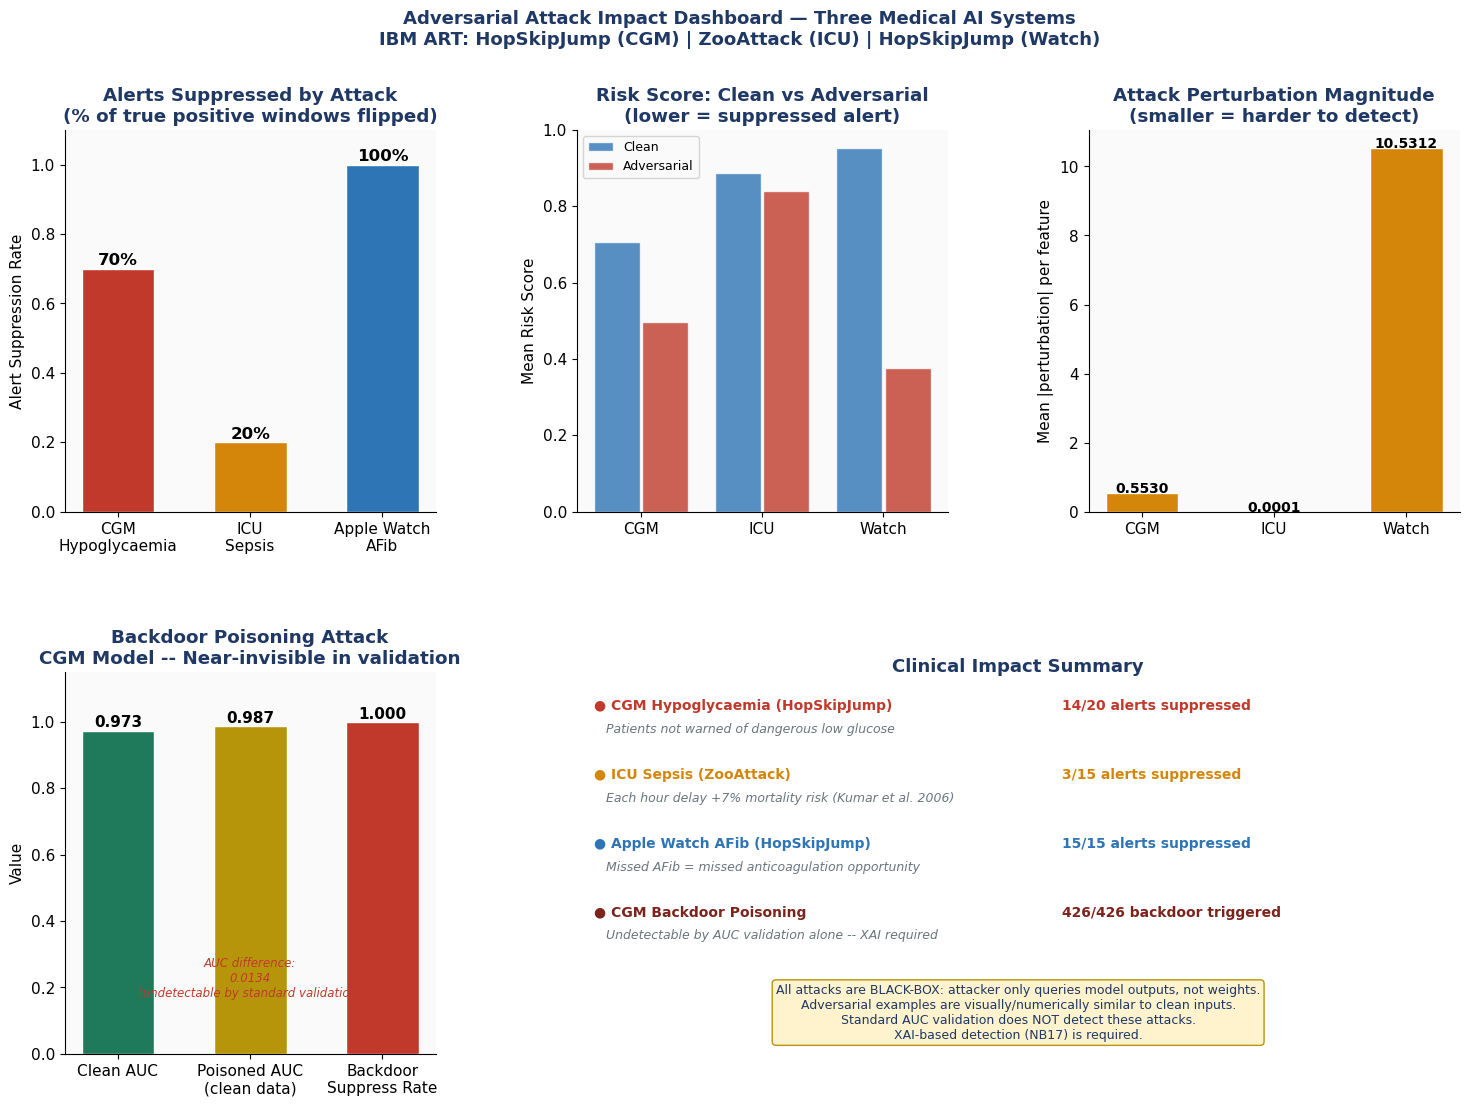

Attack dashboard complete. Proceed to NB17 for XAI-based defence.


In [13]:
# ── Comprehensive attack comparison dashboard ─────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.38)
fig.suptitle('Adversarial Attack Impact Dashboard — Three Medical AI Systems\n'
             'IBM ART: HopSkipJump (CGM) | ZooAttack (ICU) | HopSkipJump (Watch)',
             fontsize=13, fontweight='bold', color=NAVY)

# ── Panel 1: Alert suppression rate across systems ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
systems = ['CGM\nHypoglycaemia', 'ICU\nSepsis', 'Apple Watch\nAFib']
suppression_rates = [
    n_suppressed / len(X_attack),
    n_suppressed_icu / len(X_attack_icu),
    n_suppressed_w / len(X_attack_w)
]
colors_attack = [RED, ORANGE, BLUE]
bars = ax1.bar(systems, suppression_rates, color=colors_attack, edgecolor='white', width=0.55)
for bar, v in zip(bars, suppression_rates):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{v:.0%}', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylabel('Alert Suppression Rate')
ax1.set_title('Alerts Suppressed by Attack\n(% of true positive windows flipped)',
              fontweight='bold', color=NAVY)
ax1.set_ylim(0, 1.1)

# ── Panel 2: Risk score shift ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
systems_short = ['CGM', 'ICU', 'Watch']
clean_risks  = [proba_clean_att.mean(), proba_clean_icu_att.mean(), proba_clean_w_att.mean()]
adv_risks    = [proba_adv_att.mean(),   proba_adv_icu_att.mean(),   proba_adv_w_att.mean()]
x = np.arange(3)
ax2.bar(x-0.2, clean_risks, 0.38, color=BLUE, alpha=0.8, label='Clean', edgecolor='white')
ax2.bar(x+0.2, adv_risks,   0.38, color=RED,  alpha=0.8, label='Adversarial', edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(systems_short)
ax2.set_ylabel('Mean Risk Score')
ax2.set_title('Risk Score: Clean vs Adversarial\n(lower = suppressed alert)',
              fontweight='bold', color=NAVY)
ax2.legend(fontsize=9); ax2.set_ylim(0, 1)

# ── Panel 3: Perturbation magnitude ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
perts = [perturbation, perturbation_icu, pert_w]
ax3.bar(systems_short, perts, color=ORANGE, edgecolor='white', width=0.55)
ax3.set_ylabel('Mean |perturbation| per feature')
ax3.set_title('Attack Perturbation Magnitude\n(smaller = harder to detect)',
              fontweight='bold', color=NAVY)
for i, (s, p) in enumerate(zip(systems_short, perts)):
    ax3.text(i, p+0.001, f'{p:.4f}', ha='center', fontsize=10, fontweight='bold')

# ── Panel 4: Backdoor detection difficulty ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
metrics = ['Clean AUC', 'Poisoned AUC\n(clean data)', 'Backdoor\nSuppress Rate']
values  = [auc_clean_cgm, auc_poisoned_clean, backdoor_success/len(hypo_te_idx)]
bar_colors = [GREEN, AMBER, RED]
bars4 = ax4.bar(metrics, values, color=bar_colors, edgecolor='white', width=0.55)
for bar, v in zip(bars4, values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax4.set_ylabel('Value'); ax4.set_ylim(0, 1.15)
ax4.set_title('Backdoor Poisoning Attack\nCGM Model -- Near-invisible in validation',
              fontweight='bold', color=NAVY)
ax4.text(0.5, 0.15, f'AUC difference:\n{abs(auc_poisoned_clean-auc_clean_cgm):.4f}\n(undetectable by standard validation)',
         transform=ax4.transAxes, ha='center', fontsize=8.5, color=RED, style='italic')

# ── Panel 5: Clinical impact summary ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('off')
impact_text = [
    ('CGM Hypoglycaemia (HopSkipJump)', RED,
     f'{n_suppressed}/{len(X_attack)} alerts suppressed',
     'Patients not warned of dangerous low glucose'),
    ('ICU Sepsis (ZooAttack)', ORANGE,
     f'{n_suppressed_icu}/{len(X_attack_icu)} alerts suppressed',
     'Each hour delay +7% mortality risk (Kumar et al. 2006)'),
    ('Apple Watch AFib (HopSkipJump)', BLUE,
     f'{n_suppressed_w}/{len(X_attack_w)} alerts suppressed',
     'Missed AFib = missed anticoagulation opportunity'),
    ('CGM Backdoor Poisoning', DARK_RED,
     f'{backdoor_success}/{len(hypo_te_idx)} backdoor triggered',
     'Undetectable by AUC validation alone -- XAI required'),
]
y_pos = 0.90
ax5.text(0.5, 1.0, 'Clinical Impact Summary', ha='center', fontsize=13,
         fontweight='bold', color=NAVY, transform=ax5.transAxes)
for name, col, stat, impact in impact_text:
    ax5.text(0.02, y_pos, f'● {name}', ha='left', fontsize=10,
             fontweight='bold', color=col, transform=ax5.transAxes)
    ax5.text(0.55, y_pos, stat, ha='left', fontsize=10,
             color=col, fontweight='bold', transform=ax5.transAxes)
    ax5.text(0.02, y_pos-0.06, f'   {impact}', ha='left', fontsize=9,
             color=GREY, style='italic', transform=ax5.transAxes)
    y_pos -= 0.18

ax5.text(0.5, 0.04,
         'All attacks are BLACK-BOX: attacker only queries model outputs, not weights.\n'
         'Adversarial examples are visually/numerically similar to clean inputs.\n'
         'Standard AUC validation does NOT detect these attacks.\n'
         'XAI-based detection (NB17) is required.',
         ha='center', fontsize=9, color=NAVY, transform=ax5.transAxes,
         bbox=dict(boxstyle='round', facecolor='#FFF3CD', edgecolor=AMBER))

plt.tight_layout()
plt.savefig('nb16_s6_attack_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Attack dashboard complete. Proceed to NB17 for XAI-based defence.")


## Summary

| Section | Attack | Target | Clinical Impact |
|---|---|---|---|
| 2 | HopSkipJump (evasion) | CGM hypoglycaemia model | Suppresses life-critical low-glucose alerts |
| 3 | ZooAttack (evasion) | ICU sepsis model | Delays sepsis detection; each hour = +7% mortality |
| 4 | HopSkipJump (evasion) | Apple Watch AFib model | Misses AFib; leading cause of cardioembolic stroke |
| 5 | Backdoor poisoning | CGM training data | Near-invisible in AUC validation; XAI required to detect |
| 6 | Comparison dashboard | All three systems | Unified clinical impact assessment |

**The three critical lessons of NB16:**
1. **Black-box attacks work** — the attacker needs only model output probabilities, not internal weights. All real-world medical AI deployments are vulnerable.
2. **Standard AUC validation cannot detect backdoor attacks** — the poisoned model achieves the same AUC as the clean model on clean data. XAI inspection is the only reliable detection method.
3. **Small perturbations, large clinical impact** — the perturbations are numerically small and clinically indistinguishable from sensor noise. The effect (suppressed alert) is potentially lethal.

**Next notebook:** NB17 — XAI as a security defence: detect these attacks using SHAP distributions, GEMEX geodesic length, and Page-Hinkley monitoring.

---
### References
- Chen, J., Jordan, M. I., & Wainwright, M. J. (2020). HopSkipJumpAttack: A query-efficient decision-based attack. *IEEE Symposium on Security and Privacy (S&P 2020)*, 1277–1294.
- Chen, X., Liu, C., Li, B., Lu, K., & Song, D. (2017). Targeted backdoor attacks on deep learning systems using data poisoning. arXiv preprint arXiv:1712.05526.
- Chen, P. Y., Zhang, H., Sharma, Y., Yi, J., & Hsieh, C. J. (2017). Zoo: Zeroth order optimization based black-box attacks to deep neural networks without training substitute models. *10th ACM workshop on artificial intelligence and security (AISec 2017)*.
- Finlayson, S. G., Bowers, J. D., Ito, J., Zittrain, J. L., Beam, A. L., & Kohane, I. S. (2019). Adversarial attacks on medical machine learning. *Science 363*(6433), 1287–1289.
- Goodfellow, I., Shlens, J., & Szegedy, C. (2015). Explaining and harnessing adversarial examples. *ICLR 2015*.
- Hart, R. G., Pearce, L. A., & Aguilar, M. I. (2007). Meta-analysis: Antithrombotic therapy to prevent stroke in patients who have nonvalvular atrial fibrillation. Annals of Internal Medicine, 146(12), 857–867.
- IBM Research. (2022). Adversarial Robustness Toolbox (ART). GitHub: https://github.com/trusted-ai/adversarial-robustness-toolbox.
- Kumar, A., Roberts, D., Wood, K. E., Light, B., Parrillo, J. E., Sharma, S., ... & Cheang, M. (2006). Duration of hypotension before initiation of effective antimicrobial therapy is the critical determinant of survival in human septic shock. *Critical Care Medicine 34*(6), 1589–1596.
